# H5T0_MLP: implement an MLP using PyTorch for image classification

### create your "signature":
#### Run the cell but do NOT modify the cell
#### The signature needs to be displayed right below the cell in this file

In [1]:
import platform, socket, getpass
from time import time
from datetime import datetime
import random
signature_for_mlp=[socket.gethostbyname(socket.gethostname()),
                   getpass.getuser(),
                   datetime.now(),
                   random.random()]
print(signature_for_mlp) 

['127.0.0.1', 'jademuyambo', datetime.datetime(2025, 11, 28, 0, 54, 37, 999575), 0.8937578598790831]


In [2]:
#sample code to save model and signature
#torch.save({"model":model.state_dict(),
#            "signature":signature_for_mlp},
#            "MLP_best.pt") 

### This is a complete application of image classification using an MLP
steps: \
define an MLP \
define a function for training the MLP \
define a function for testing the MLP \
define a function for saving the model and your `signature_for_mlp` \
load data \
train the MLP in a for loop using the training set and the validation set\
evalaute the best model on the test set\
display accuracy and confusion matrix for each of the three sets: train, validation, and test sets
### you may use the code in lecture nodes
### write your code below this line

In [362]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [363]:
data = torch.load("H5T0_train_val_test_data.pt", weights_only=False, map_location="cpu")

X_train = data["X_train"]
Y_train = data["Y_train"]
X_val = data["X_val"]
Y_val = data["Y_val"]
X_test = data["X_test"]
Y_test = data["Y_test"]

print("X shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Y shapes:", Y_train.shape, Y_val.shape, Y_test.shape)
print("X range:", float(X_train.min()), float(X_train.max()))
print("dtypes:", X_train.dtype, Y_train.dtype)



X shapes: (1000, 28, 28) (1000, 28, 28) (1000, 28, 28)
Y shapes: (1000,) (1000,) (1000,)
X range: 0.0 1.0
dtypes: float32 int64


In [364]:
mu = float(X_train.mean())
sigma = float(X_train.std() + 1e-6)

class FashionDataset(Dataset):
    def __init__(self, X, Y, mu, sigma):
        self.X = torch.tensor(X).float()
        self.Y = torch.tensor(Y).long()
        self.mu = torch.tensor(mu).float()
        self.sigma = torch.tensor(sigma).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        x = (x - self.mu) / self.sigma
        return x, self.Y[idx]

batch_size = 128

train_loader = DataLoader(FashionDataset(X_train, Y_train, mu, sigma), batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(FashionDataset(X_val, Y_val, mu, sigma), batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(FashionDataset(X_test, Y_test, mu, sigma), batch_size=batch_size, shuffle=False, num_workers=0)


In [459]:
class MLP(nn.Module):
    def __init__(self, in_dim=28*28, num_classes=10, dropout=0.30):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = nn.Linear(256, num_classes)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        if x.dim() == 4:
            x = x.squeeze(1)
        x = x.view(x.size(0), -1)

        x = self.drop(F.relu(self.bn1(self.fc1(x))))
        x = self.drop(F.relu(self.bn2(self.fc2(x))))
        x = self.drop(F.relu(self.bn3(self.fc3(x))))
        return self.fc4(x)

In [477]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)

print("device:", device)


device: cpu


In [478]:
def accuracy_from_logits(logits, y):
    pred = torch.argmax(logits, dim=1)
    return (pred == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_correct = 0
    total = 0
    all_pred = []
    all_true = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)

        total_correct += (pred == y).sum().item()
        total += y.size(0)

        all_pred.append(pred.cpu())
        all_true.append(y.cpu())

    acc = total_correct / total
    all_pred = torch.cat(all_pred).numpy()
    all_true = torch.cat(all_true).numpy()
    return acc, all_true, all_pred

def confusion_matrix_np(y_true, y_pred, num_classes=10):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

In [479]:
num_epochs = 100

best_val_acc = -1.0
best_epoch = -1

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        pred = torch.argmax(logits, dim=1)
        running_correct += (pred == y).sum().item()
        running_total += y.size(0)

    scheduler.step()
    
    train_loss = running_loss / running_total
    train_acc = running_correct / running_total

    val_acc, _, _ = evaluate(model, val_loader)

    print(f"epoch {epoch:02d} | train loss {train_loss:.4f} | train acc {train_acc:.4f} | val acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state-dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "signature": signature_for_mlp,
                "other": signature_for_mlp,
            },
            "MLP_best.pt"
        )

print("\nBest epoch:", best_epoch, "best val acc:", best_val_acc)
print("Saved: MLP_best.pt")
                
    

epoch 00 | train loss 1.4440 | train acc 0.5430 | val acc 0.6820
epoch 01 | train loss 0.7960 | train acc 0.7450 | val acc 0.7330
epoch 02 | train loss 0.6269 | train acc 0.7980 | val acc 0.7580
epoch 03 | train loss 0.4939 | train acc 0.8300 | val acc 0.7800
epoch 04 | train loss 0.4145 | train acc 0.8600 | val acc 0.8060
epoch 05 | train loss 0.3523 | train acc 0.8860 | val acc 0.8030
epoch 06 | train loss 0.2862 | train acc 0.9210 | val acc 0.8060
epoch 07 | train loss 0.2628 | train acc 0.9130 | val acc 0.8070
epoch 08 | train loss 0.2034 | train acc 0.9430 | val acc 0.7880
epoch 09 | train loss 0.1902 | train acc 0.9380 | val acc 0.7910
epoch 10 | train loss 0.1596 | train acc 0.9530 | val acc 0.8210
epoch 11 | train loss 0.1342 | train acc 0.9560 | val acc 0.8070
epoch 12 | train loss 0.1167 | train acc 0.9720 | val acc 0.8140
epoch 13 | train loss 0.1163 | train acc 0.9610 | val acc 0.7940
epoch 14 | train loss 0.1070 | train acc 0.9690 | val acc 0.7800
epoch 15 | train loss 0.1

In [480]:
ckpt = torch.load("MLP_best.pt", weights_only=False, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval

train_acc, ytr, ptr = evaluate(model, train_loader)
val_acc, yv, pv = evaluate(model, val_loader)
test_acc, yte, pte = evaluate(model, test_loader)

cm_train = confusion_matrix_np(ytr, ptr, num_classes=10)
cm_val = confusion_matrix_np(yv, pv, num_classes=10)
cm_test = confusion_matrix_np(yte, pte, num_classes=10)

print("Accuracy train:", train_acc)
print("Accuracy val  :", val_acc)
print("Accuracy test :", test_acc)

Accuracy train: 1.0
Accuracy val  : 0.832
Accuracy test : 0.817


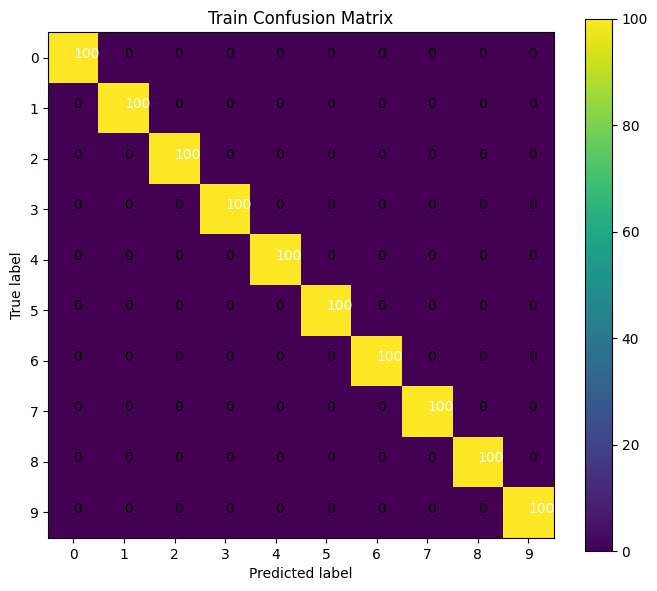

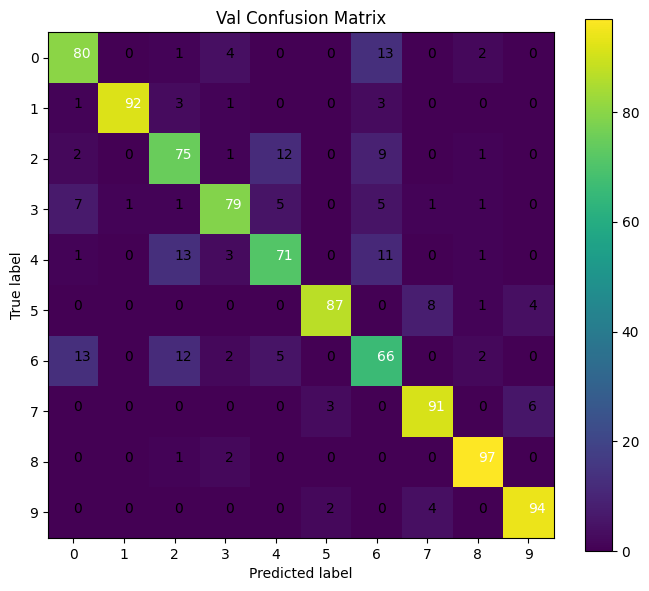

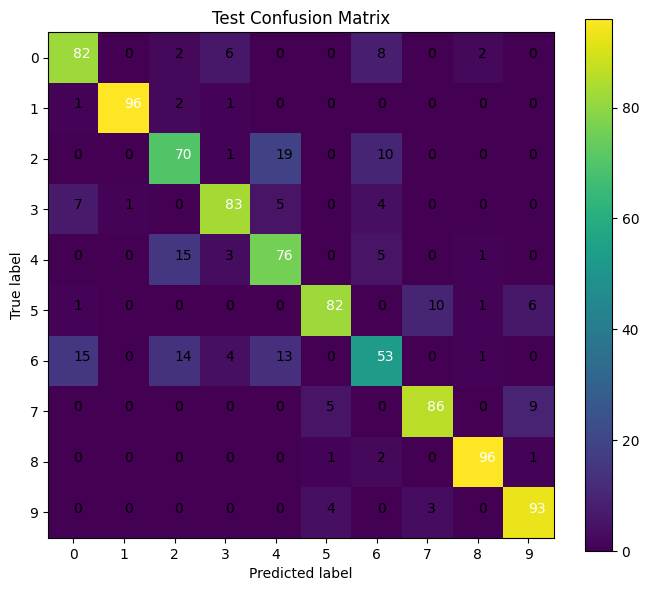

In [481]:
def plot_confusion_matrix(cm, title="Confusion matrix", show_ticks=True):
    cm = np.array(cm)

    fig, ax = plt.subplots(figsize=(7,6))
    im = ax.imshow(cm, interpolation="nearest")
    ax.figure.colorbar(im, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    if show_ticks:
        ticks = np.arange(cm.shape[0])
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{int(cm[i, j])}",
                    color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()
    plt.show()

plot_confusion_matrix(cm_train, title="Train Confusion Matrix", show_ticks=True)
plot_confusion_matrix(cm_val, title="Val Confusion Matrix", show_ticks=True)
plot_confusion_matrix(cm_test, title="Test Confusion Matrix", show_ticks=True)